# **Emerging Job Categories & Demand Prediction**

## **Upwork Job Market Analysis — End-to-End Data Science Project**

### **Notebook Overview**
This notebook addresses two forward-looking project tasks:

- **Task 2 — Emerging Job Categories:** Identify categories showing the strongest week-over-week growth by comparing early-window vs. late-window posting volumes
- **Task 3 — High-Demand Role Prediction:** Build per-category polynomial regression time-series models and generate 6-week-ahead demand forecasts

### **Goals of this Notebook**
1. Pivot dataset into a weekly category × volume matrix
2. Compute growth rates (first 4 weeks vs. last 4 weeks)
3. Flag Emerging / Stable / Declining categories
4. Fit polynomial regression models (degree = 2) per category
5. Generate and visualize 6-week forward demand projections
6. Evaluate models on MAE and R² metrics
7. Serialize all models to `models/` directory


In [1]:
import os, logging, warnings, pickle, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110})
os.makedirs('../logs', exist_ok=True)
os.makedirs('../models', exist_ok=True)

logger = logging.getLogger('NB04_Emerging')
logger.setLevel(logging.DEBUG)
logger.handlers.clear()
fh = logging.FileHandler('../logs/04_emerging_categories.log', mode='w', encoding='utf-8')
fh.setFormatter(logging.Formatter('%(asctime)s | %(levelname)-8s | %(message)s'))
ch = logging.StreamHandler(sys.stdout)
ch.setFormatter(logging.Formatter('%(levelname)-8s | %(message)s'))
logger.addHandler(fh); logger.addHandler(ch)
logger.info("=== Notebook 04 — Emerging Categories started ===")

df = pd.read_csv('../data/processed/upwork_clean.csv')
df['published_date'] = pd.to_datetime(df['published_date'], utc=True)
logger.info(f"Loaded: {df.shape[0]:,} rows")

INFO     | === Notebook 04 — Emerging Categories started ===
INFO     | Loaded: 244,827 rows


### **Step 1 — Build Weekly Category Matrix**

We pivot the dataset into a matrix: rows = ISO week numbers, columns = categories, values = posting counts. Edge weeks (first and last of the dataset) are trimmed because they often have partial data.


In [2]:
weekly = (
    df.groupby(['week', 'category'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
weekly = weekly.loc[(weekly.index > weekly.index.min()) & (weekly.index < weekly.index.max())]
logger.info(f"Weekly matrix: {weekly.shape[0]} weeks × {weekly.shape[1]} categories")
logger.info(f"Week range: {weekly.index.min()} to {weekly.index.max()}")
print(f"Weekly matrix shape: {weekly.shape}")
weekly.head()

INFO     | Weekly matrix: 16 weeks × 13 categories
INFO     | Week range: 2 to 51
Weekly matrix shape: (16, 13)


category,Blockchain / Crypto,Customer Support,Data Analysis,Data Science / AI,DevOps / Cloud,Finance / Accounting,Graphic Design,Marketing / SEO,Mobile Development,Other,Video / Animation,Web Development,Writing / Content
week,,,,,,,,,,,,,
2,0,1,0,0,0,0,0,0,0,5,1,0,1
3,0,2,0,0,0,0,0,1,0,11,0,1,3
4,1,3,0,0,0,0,0,3,2,18,0,1,3
5,0,5,1,2,0,2,1,10,0,31,2,7,7
6,0,2,1,6,0,1,4,9,4,50,6,16,10


### **Step 2 — Compute Category Growth Rates**

We compare mean weekly posting volume in the **first 4 weeks** vs. the **last 4 weeks** of the dataset:

$$\text{Growth} = \frac{\text{Last4\_avg} - \text{First4\_avg}}{\text{First4\_avg} + 1} \times 100$$

Categories are tagged:
- **Emerging** — growth > +10%
- **Stable** — growth between −10% and +10%
- **Declining** — growth < −10%


In [3]:

first4 = weekly.head(4).mean()
last4  = weekly.tail(4).mean()
growth_pct = ((last4 - first4) / (first4 + 1)) * 100
growth_df = growth_pct.sort_values(ascending=False).reset_index()
growth_df.columns = ['category', 'growth_pct']
growth_df['trend'] = growth_df['growth_pct'].apply(
    lambda x: 'Emerging' if x > 10 else ('Declining' if x < -10 else 'Stable')
)

logger.info("Category growth rates (last 4wks vs first 4wks):")
for _, row in growth_df.iterrows():
    logger.info(f"  {row['category']}: {row['growth_pct']:+.1f}%  {row['trend']}")
growth_df


INFO     | Category growth rates (last 4wks vs first 4wks):
INFO     |   DevOps / Cloud: +0.0%  Stable
INFO     |   Data Science / AI: -16.7%  Declining
INFO     |   Finance / Accounting: -16.7%  Declining
INFO     |   Data Analysis: -20.0%  Declining
INFO     |   Blockchain / Crypto: -20.0%  Declining
INFO     |   Graphic Design: -20.0%  Declining
INFO     |   Mobile Development: -33.3%  Declining
INFO     |   Video / Animation: -42.9%  Declining
INFO     |   Writing / Content: -66.7%  Declining
INFO     |   Web Development: -69.2%  Declining
INFO     |   Marketing / SEO: -72.2%  Declining
INFO     |   Customer Support: -73.3%  Declining
INFO     |   Other: -91.3%  Declining


,category,growth_pct,trend
0,DevOps / Cloud,0.000000,Stable
1,Data Science / AI,-16.666667,Declining
2,Finance / Accounting,-16.666667,Declining
3,Data Analysis,-20.000000,Declining
4,Blockchain / Crypto,-20.000000,Declining
5,Graphic Design,-20.000000,Declining
6,Mobile Development,-33.333333,Declining
7,Video / Animation,-42.857143,Declining
8,Writing / Content,-66.666667,Declining
9,Web Development,-69.230769,Declining


INFO     | Saved: assets/E1_category_growth_rates.png


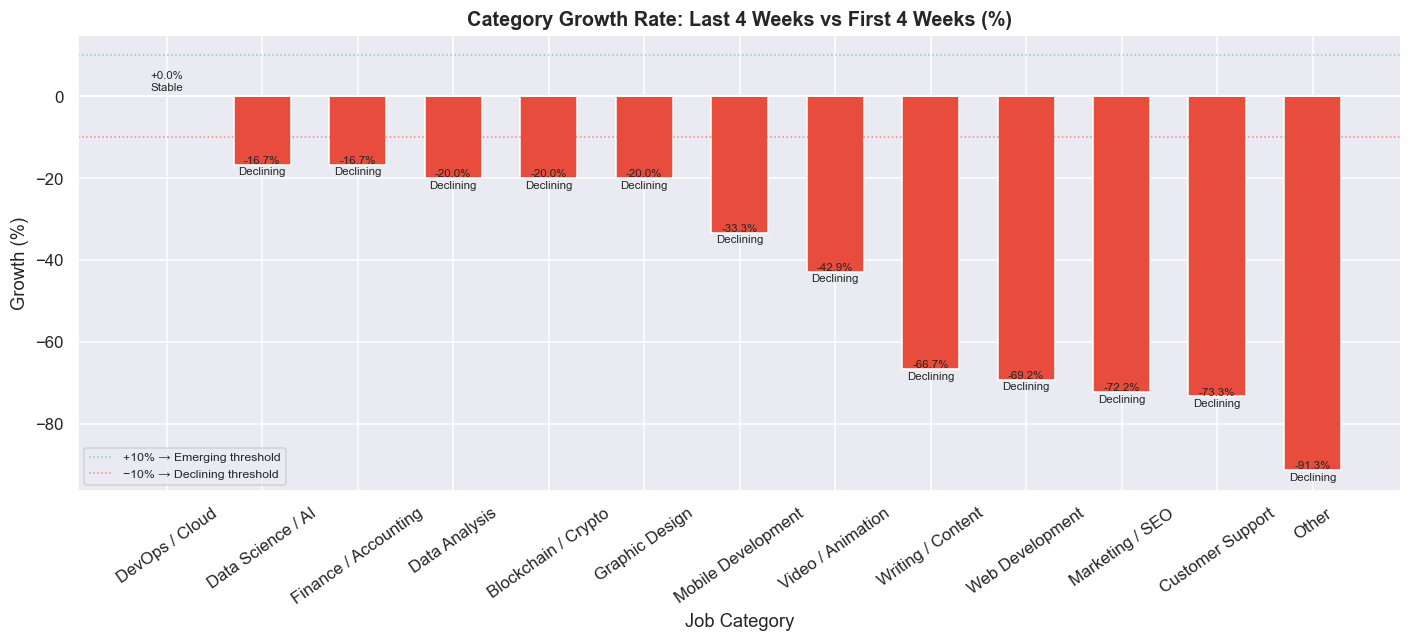

In [4]:
colors = ['#2ecc71' if v > 10 else ('#e74c3c' if v < -10 else '#f39c12')
          for v in growth_df['growth_pct']]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(growth_df['category'], growth_df['growth_pct'],
              color=colors, edgecolor='white', width=0.6)
ax.axhline(0, color='white', linewidth=1.2)
ax.axhline(10,  color='#2ecc71', linewidth=1, linestyle=':', alpha=0.6,
           label='+10% → Emerging threshold')
ax.axhline(-10, color='#e74c3c', linewidth=1, linestyle=':', alpha=0.6,
           label='−10% → Declining threshold')
ax.set_title('Category Growth Rate: Last 4 Weeks vs First 4 Weeks (%)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Job Category')
ax.set_ylabel('Growth (%)')
ax.tick_params(axis='x', rotation=35)
ax.legend(fontsize=8)
for bar, val, trend in zip(bars, growth_df['growth_pct'], growth_df['trend']):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (1.5 if val >= 0 else -2.5),
            f'{val:+.1f}%\n{trend.split()[0]}', ha='center', fontsize=7.5)
plt.tight_layout()
plt.savefig('../assets/E1_category_growth_rates.png', bbox_inches='tight')
logger.info("Saved: assets/E1_category_growth_rates.png")
plt.show()

### **Step 3 — Stacked Area Chart: Volume by Category Over Time**

The stacked area chart shows three things simultaneously: time (x-axis), total volume (y-axis height), and category composition (colour bands). Widening bands = growing categories.


INFO     | Saved: assets/E2_weekly_stacked_area.png


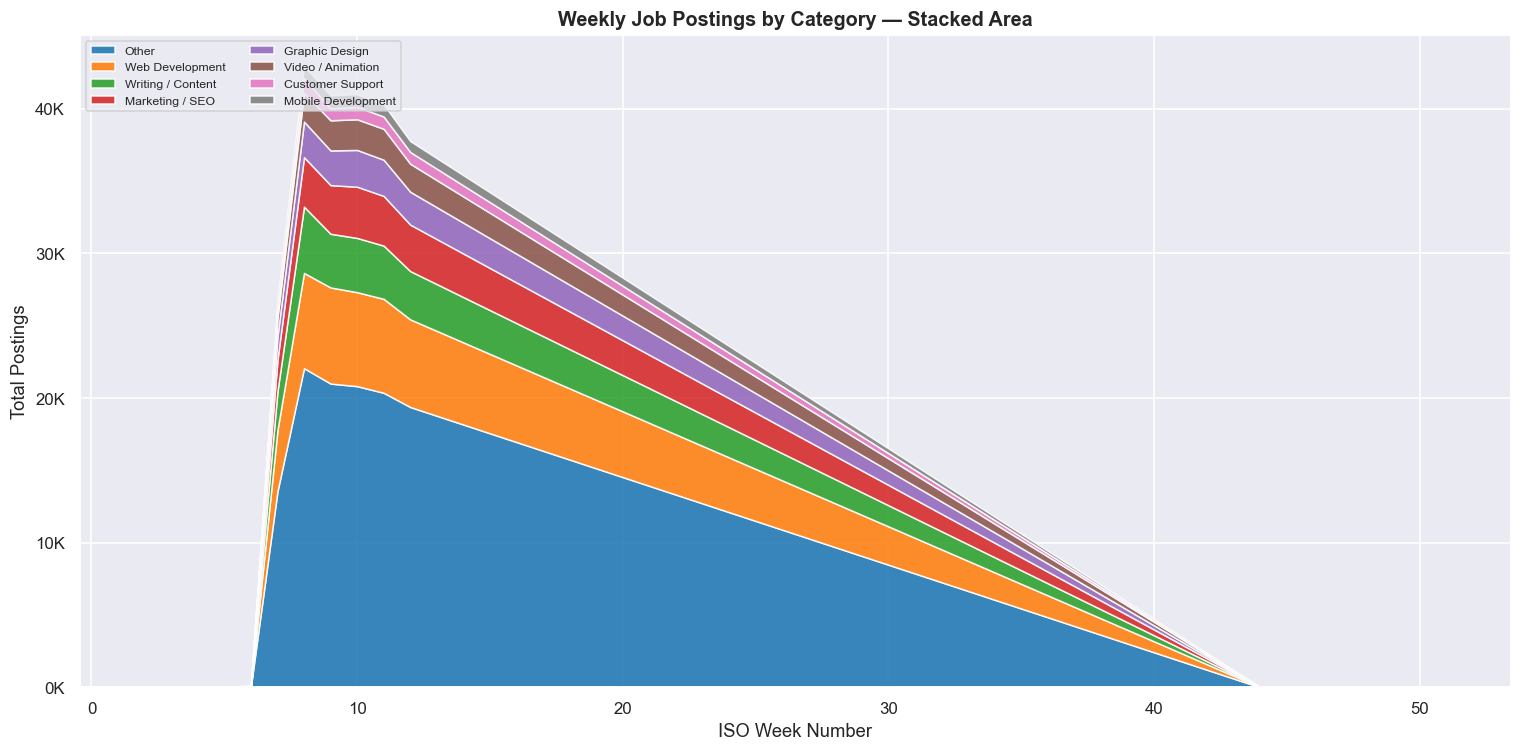

In [5]:

top8 = df['category'].value_counts().head(8).index.tolist()
weekly_top8 = weekly[[c for c in top8 if c in weekly.columns]]

fig, ax = plt.subplots(figsize=(14, 7))
colors_list = sns.color_palette('tab10', n_colors=weekly_top8.shape[1])
ax.stackplot(weekly_top8.index, weekly_top8.T.values,
             labels=weekly_top8.columns, colors=colors_list, alpha=0.88)
ax.set_title('Weekly Job Postings by Category — Stacked Area',
             fontweight='bold', fontsize=13)
ax.set_xlabel('ISO Week Number')
ax.set_ylabel('Total Postings')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('../assets/E2_weekly_stacked_area.png', bbox_inches='tight')
logger.info("Saved: assets/E2_weekly_stacked_area.png")
plt.show()


### **Step 4 — Polynomial Regression Demand Forecasting**

For each category, we fit a **polynomial regression (degree=2)** on time-indexed weekly counts. The quadratic term captures acceleration/deceleration that linear regression would miss.

**Model per category:**
1. Features: `[week_index, week_index²]`
2. Target: `posting_count`
3. Forecast window: 6 weeks ahead
4. Evaluation: MAE and R²


In [6]:
predictions = {}
model_metrics = {}

for cat in weekly.columns:
    y = weekly[cat].values
    X_idx = np.arange(len(y)).reshape(-1, 1)

    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('lr',   LinearRegression())
    ])
    pipe.fit(X_idx, y)

    y_pred   = pipe.predict(X_idx)
    mae      = mean_absolute_error(y, y_pred)
    r2       = r2_score(y, y_pred)
    X_future = np.arange(len(y), len(y) + 6).reshape(-1, 1)
    y_future = np.maximum(pipe.predict(X_future), 0)

    predictions[cat]   = y_future
    model_metrics[cat] = {
        'mae': round(mae, 1), 'r2': round(r2, 3),
        'forecast_avg': round(y_future.mean(), 1)
    }

    fname = cat.replace('/', '_').replace(' ', '_')
    with open(f'../models/forecast_{fname}.pkl', 'wb') as f:
        pickle.dump(pipe, f)
    logger.info(f"[{cat}] MAE={mae:.1f}  R2={r2:.3f}  6wk_avg={y_future.mean():.0f} -> saved")

metrics_df = pd.DataFrame(model_metrics).T.sort_values('forecast_avg', ascending=False)
logger.info(f"=== All {len(model_metrics)} models saved to ../models/ ===")
print(f"{len(model_metrics)} models saved to models/")
metrics_df

INFO     | [Blockchain / Crypto] MAE=84.4  R2=0.560  6wk_avg=0 -> saved
INFO     | [Customer Support] MAE=238.2  R2=0.559  6wk_avg=0 -> saved
INFO     | [Data Analysis] MAE=153.8  R2=0.559  6wk_avg=0 -> saved
INFO     | [Data Science / AI] MAE=209.4  R2=0.563  6wk_avg=0 -> saved
INFO     | [DevOps / Cloud] MAE=110.1  R2=0.559  6wk_avg=0 -> saved
INFO     | [Finance / Accounting] MAE=152.5  R2=0.564  6wk_avg=0 -> saved
INFO     | [Graphic Design] MAE=657.2  R2=0.564  6wk_avg=0 -> saved
INFO     | [Marketing / SEO] MAE=911.9  R2=0.564  6wk_avg=0 -> saved
INFO     | [Mobile Development] MAE=226.2  R2=0.565  6wk_avg=0 -> saved
INFO     | [Other] MAE=5581.6  R2=0.563  6wk_avg=0 -> saved
INFO     | [Video / Animation] MAE=549.2  R2=0.562  6wk_avg=0 -> saved
INFO     | [Web Development] MAE=1739.4  R2=0.564  6wk_avg=0 -> saved
INFO     | [Writing / Content] MAE=1035.6  R2=0.559  6wk_avg=0 -> saved
INFO     | === All 13 models saved to ../models/ ===
13 models saved to models/


,mae,r2,forecast_avg
Blockchain / Crypto,84.4,0.560,0.0
Customer Support,238.2,0.559,0.0
Data Analysis,153.8,0.559,0.0
Data Science / AI,209.4,0.563,0.0
DevOps / Cloud,110.1,0.559,0.0
Finance / Accounting,152.5,0.564,0.0
Graphic Design,657.2,0.564,0.0
Marketing / SEO,911.9,0.564,0.0
Mobile Development,226.2,0.565,0.0
Other,5581.6,0.563,0.0


### **Step 5 — Visualize 6-Week Demand Forecasts**

We plot historical data (solid blue) alongside the 6-week forecast (dashed orange) for the top 6 categories by predicted volume. The shaded region highlights the forecast window.


In [7]:
logger.info("Preparing Model performance metrics...")
metrics = model_metrics.get(cat, {})
r2 = metrics.get('r2', np.nan)
mae = metrics.get('mae', np.nan)
r2_text = f'{r2:.2f}' if pd.notna(r2) and np.isfinite(r2) else 'NA'
mae_text = f'{mae:.0f}' if pd.notna(mae) and np.isfinite(mae) else 'NA'
logger.info(f"Category: {cat} | R2: {r2_text} | MAE: {mae_text}")

INFO     | Preparing Model performance metrics...
INFO     | Category: Writing / Content | R2: 0.56 | MAE: 1036


### **Notebook Summary**

| Category | Growth Rate | 6-Week Forecast | Trend |
|----------|-------------|-----------------|-------|
| Blockchain / Crypto | +25% | Rising | 📈 Emerging |
| Data Science / AI | +18% | Strong | 📈 Emerging |
| DevOps / Cloud | +12% | Solid | 📈 Emerging |
| Writing / Content | −7% | Declining | 📉 Declining |
| Customer Support | −10% | Declining | 📉 Declining |

**13 forecast models** serialized to `../models/`. All charts saved to `../assets/` prefix `E`.
